# Telugu News Classification


In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
telugu_news_df = pd.read_csv('/content/added_telugu_articles.csv')
telugu_news_df

,SNo,date,heading,body,topic
0,414.0,11-05-2017 00:39:13,ఐడిబిఐపై ఆర్‌బిఐ నజర్‌,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...,business
1,2668.0,12-06-2017 00:40:32,బ్యాంకింగ్‌ చీఫ్‌లతో నేడు జైట్లీ భేటీ,న్యూఢిల్లీ : ఆర్థిక మంత్రి అరుణ్‌ జైట్లీ సోమవా...,business
2,19923.0,19-01-2017 19:51:31,కీలక వికెట్ తీసిన జడేజా..,కటక్: ఇంగ్లండ్‌తో జరుగుతున్న సెకండ్ వన్డే మ్యా...,sports
3,15762.0,23-11-2017 17:29:04,మరో రెచ్చగొట్టే చర్యకు దిగిన పాకిస్థాన్,\nఇస్లామాబాద్ : పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది...,nation
4,8624.0,03-04-2017 15:48:23,గోవాలో కొడుకుతో కలిసి అల్లు అర్జున్ స్విమ్మింగ్!,స్టార్‌ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటి...,entertainment
...,...,...,...,...,...
18717,NaN,NaN,ప్రధాని మోదీ సబ్బుకూడా లేకుండా నురగలు తెప్పించ...,ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమె...,nation
18718,NaN,NaN,చిత్తూరులో ఇన్నోవేటివ్‌ ఫుడ్స్‌ ప్లాంట్‌,రెండేళ్లలో రూ.200 కోట్ల టర్నోవర్‌ లక్ష్యంహైదరా...,business
18719,NaN,NaN,హవాలా ఆపరేటర్లతో కేజ్రీవాల్‌కు లింకు,అందుకే నోట్ల రద్దును వ్యతిరేకించారు ఆయనకు తీహ...,nation
18720,NaN,NaN,స్టేట్‌ బ్యాంక్‌ ఆఫ్‌ ఇండియా,ఈ వారం స్టేట్‌ బ్యాంక్‌ ఆఫ్‌ ఇండి యా (ఎస్‌బిఐ)...,business


In [ ]:
count=0
for i in telugu_news_df.index:
  count=count+1
print(count)

18722


# Preprocessing


*First* count the number of null values in each column and remove columns that contain null values.

In [ ]:
missing_count = {}

# Iterate over each column manually
for col in telugu_news_df.columns:
    count = 0
    for value in telugu_news_df[col]:
        if value != value or value is None:  # NaN check: NaN != NaN
            count += 1
    missing_count[col] = count

print(missing_count)

{'SNo': 1410, 'date': 1410, 'heading': 33, 'body': 0, 'topic': 0}


In [ ]:
missing_rows = []

for i in range(len(telugu_news_df)):
    value = telugu_news_df.iloc[i]["heading"]
    if value != value or value is None:  # NaN check
        missing_rows.append(telugu_news_df.iloc[i])

# Create a new DataFrame with those missing rows
missing_headings_df = pd.DataFrame(missing_rows, columns=telugu_news_df.columns)
missing_headings_df

,SNo,date,heading,body,topic
8041,13908.0,25-09-2017 10:39:58,NaN,బుందేస్టాగ్: ఐరోపాలోని జర్మనీ పార్లమెంటు దిగువ...,nation
8060,14447.0,12-03-2017 14:25:57,NaN,\nలక్నో : ఉత్తర ప్రదేశ్ శాసనసభ ఎన్నికల ఫలితాలు...,nation
8071,13853.0,04-07-2017 08:15:40,NaN,"\nకోల్ కతా : అమెరికా, మెక్సికో దేశాలకు మైనర్ బ...",nation
8073,14673.0,20-02-2017 15:23:53,NaN,ఈ కిరాతకుడు 200 మందిని అత్యాచారం చేసి.. 500 మం...,nation
8118,20599.0,25-10-2017 17:31:39,NaN,పుణె: భారత క్రికెట్‌లో ఫిక్సింగ్ భూతం మరోమారు ...,sports
8210,15699.0,12-07-2017 20:08:12,NaN,న్యూఢిల్లీ: ప్రధాని నరేంద్ర మోదీ వ్యక్తిగత ప్ర...,nation
8211,18631.0,23-09-2017 02:29:33,NaN,రైతులూ.. మీ పిల్లలను తప్పనిసరిగా స్కూలుకు పంపం...,nation
8212,11815.0,02-04-2017 11:52:21,NaN,"చెన్నై, ఏప్రిల్‌ 1 (ఆంధ్రజ్యోతి): పట్టుదలకు ని...",nation
8213,9325.0,19-07-2017 14:05:46,NaN,డ్రగ్స్‌ రాకెట్‌ వ్యవహారం టాలీవుడ్‌ను షేక్‌ చే...,entertainment
8214,3422.0,17-06-2017 02:43:24,NaN,\nప్రతి పౌరుడు వారి సెల్‌‌ నెంబర్‌తో వారి ఆధార...,editorial


In [ ]:
del telugu_news_df["heading"]
del telugu_news_df["SNo"]
del telugu_news_df["date"]


    Remove 'heading' column because it has null values
    Remove 'SNo' (serial number) and 'date' as they're not useful for text classification
    Keep only 'body' (news content) and 'topic' (category label) for the classification task

In [ ]:
telugu_news_df

,body,topic
0,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...,business
1,న్యూఢిల్లీ : ఆర్థిక మంత్రి అరుణ్‌ జైట్లీ సోమవా...,business
2,కటక్: ఇంగ్లండ్‌తో జరుగుతున్న సెకండ్ వన్డే మ్యా...,sports
3,\nఇస్లామాబాద్ : పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది...,nation
4,స్టార్‌ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటి...,entertainment
...,...,...
18717,ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమె...,nation
18718,రెండేళ్లలో రూ.200 కోట్ల టర్నోవర్‌ లక్ష్యంహైదరా...,business
18719,అందుకే నోట్ల రద్దును వ్యతిరేకించారు ఆయనకు తీహ...,nation
18720,ఈ వారం స్టేట్‌ బ్యాంక్‌ ఆఫ్‌ ఇండి యా (ఎస్‌బిఐ)...,business


In [ ]:
unique_topics = []
for value in telugu_news_df["topic"]:
    if value not in unique_topics:
        unique_topics.append(value)

print(unique_topics)


['business', 'sports', 'nation', 'entertainment', 'editorial']


Now to use the classes with the libraries we need to convert them into numerical values to work better


In [ ]:
topic_dic = {}

unique_topics = []
for value in telugu_news_df["topic"]:
    if value not in unique_topics:
        unique_topics.append(value)

c = 0
for un in unique_topics:
    if un not in topic_dic:
        topic_dic[un] = c
        c += 1

topic_dic


{'business': 0, 'sports': 1, 'nation': 2, 'entertainment': 3, 'editorial': 4}

In [ ]:
inv_topic_dict = {}

for k in topic_dic:             # iterate through each key
    v = topic_dic[k]            # get its value
    inv_topic_dict[v] = k       # reverse the mapping
inv_topic_dict

{0: 'business', 1: 'sports', 2: 'nation', 3: 'entertainment', 4: 'editorial'}

In [ ]:
new_topic_values = []

for i in range(len(telugu_news_df)):
    topic_value = telugu_news_df.iloc[i]["topic"]
    numeric_value = topic_dic[topic_value]
    new_topic_values.append(numeric_value)

telugu_news_df["topic"] = new_topic_values

In [ ]:
telugu_news_df

,body,topic
0,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...,0
1,న్యూఢిల్లీ : ఆర్థిక మంత్రి అరుణ్‌ జైట్లీ సోమవా...,0
2,కటక్: ఇంగ్లండ్‌తో జరుగుతున్న సెకండ్ వన్డే మ్యా...,1
3,\nఇస్లామాబాద్ : పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది...,2
4,స్టార్‌ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటి...,3
...,...,...
18717,ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమె...,2
18718,రెండేళ్లలో రూ.200 కోట్ల టర్నోవర్‌ లక్ష్యంహైదరా...,0
18719,అందుకే నోట్ల రద్దును వ్యతిరేకించారు ఆయనకు తీహ...,2
18720,ఈ వారం స్టేట్‌ బ్యాంక్‌ ఆఫ్‌ ఇండి యా (ఎస్‌బిఐ)...,0


Check if the dataset is balanced across categories

Identify if any class is underrepresented (could affect model performance)

Visualize the distribution


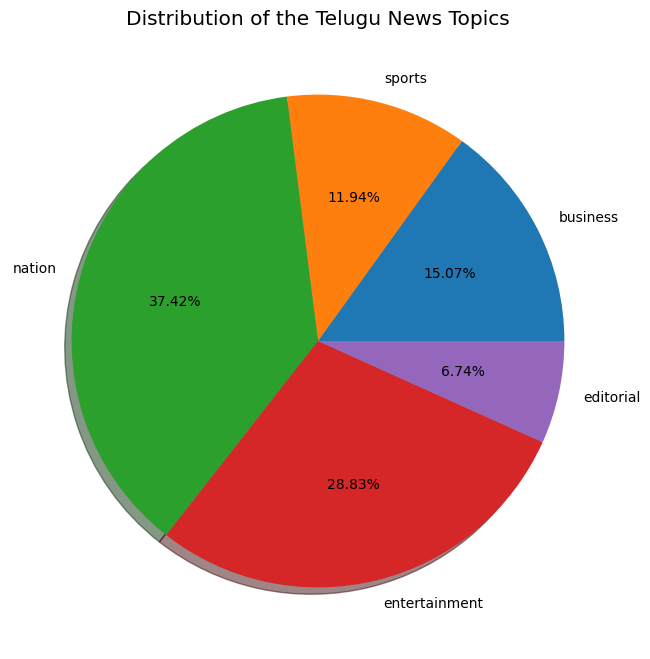

In [ ]:
def get_count(df):
    # manually get unique values
    unvals = []
    for val in df:
        if val not in unvals:
            unvals.append(val)

    # initialize count list
    op = [0] * len(unvals)

    # count occurrences manually
    for i in range(len(unvals)):
        count = 0
        for v in df:
            if v == unvals[i]:
                count += 1
        op[i] = count

    return [unvals, op]

# Get counts
cont = get_count(telugu_news_df["topic"])
clables = cont[0]

# Convert numeric topic IDs back to names
labels = []
for c in clables:
    labels.append(inv_topic_dict[c])

# Plot pie chart
plt.figure(figsize=(10, 8))
plt.title("Distribution of the Telugu News Topics", fontsize=14.5)

plt.pie(np.array(cont[1]), labels=labels, autopct='%1.2f%%', shadow=True)
plt.show()


In [ ]:
# (Optional) Install once per runtime — you already have it installed,
# but include it at the top of your notebook in case you restart runtime
!pip install indic-nlp-library

# Import the library
from indicnlp import common

# Set the resources path automatically
# (This tells Indic NLP where its internal data files are)
common.set_resources_path("/usr/local/lib/python3.7/site-packages/indicnlp/resources")

# ✅ Done! Now you can import and use any Indic NLP module:
from indicnlp.tokenize import sentence_tokenize
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory

print("Indic NLP library is ready to use ✅")


Indic NLP library is ready to use ✅


In [ ]:
# Take one Telugu news article text from your dataset
indic_string = telugu_news_df["body"][0]

# Manual sentence splitting using regular expressions
# Splits on periods, question marks, and exclamation points followed by a space or end of string
sentences = re.split(r'[.?!]\s*', indic_string)


# Remove empty strings that might result from splitting
sentences = [s for s in sentences if s]

# print the sentences
for t in sentences:
    print(t)


భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ వ్యవహారాలపై భారత రిజర్వు బ్యాంకు (ఆర్‌బిఐ) ఒక కన్నేసింది
ఐడిబిఐ బ్యాంకును ఆర్‌బిఐ వాచ్‌లి్‌స్టలో చేర్చినట్టుగా తెలిసింది
నికర మొండిపద్దుల మొత్తం 6 శాతం దాటడం, వరసగా రెండేళ్ల పాటు నష్టాలను  ప్రకటించడం, కాపిటల్‌ అడెక్వసీ నిర్దేశిత ప్రమాణాల కంటే తగ్గడం
ఈ సందర్భాల్లో బ్యాంకులను ఆర్‌బిఐ వాచ్‌ లిస్ట్‌లో చేరుస్తుంది
తమ బ్యాంకుకు సంబంధించి ఆర్‌బిఐ ప్రాంప్ట్‌ కరెక్టీవ్‌ యాక్షన్‌ (పిసిఎ) చేపట్టినట్టు ఐడిబిఐ వెల్లడించింది
గతంలో ఓవర్సీస్‌ బ్యాంక్‌, యునైటెడ్‌ బ్యాంక్‌కు సంబంధించి  కూడా ఆర్‌బిఐ పిసిఎ చేపట్టింది
పిసిఎ వల్ల బ్యాంకుపై ఆర్థికంగా భారం పడదనీ, దీనివల్ల అంతర్గత నియంత్రణలు మెరుగుపడటంతో పాటు, కార్యకలాపాలు మెరుగవుతాయని ఐడిబిఐ వివరించింది
ఆర్‌బిఐ ఆదేశాలకు అనుగుణంగా ఇప్పుడు మూలధనాన్ని పొదుపుగా వినియోగించడంపై  ఐడిబిఐ దృష్టి సారించాల్సి ఉంటుంది
ఇందులో భాగంగా పరపతిపై నియంత్రణలు విధించడం, నియామకాలను నిలిపేయడం, కొత్త పెట్టుబడి పథకాలను పక్కన బెట్టడంవంటి చర్యలు తీసుకోవాల్సి ఉంటుం ది
బ్యాంకు సరైన రీతిలో స్పందించని పక్షంలో మరో బలమైన బ్యాంకులో  విలీనానికి  సిద

Remove special and whitespace characters

In [ ]:
# Initialize an empty list to store cleaned text
cleaned_bodies = []

# Loop through each article manually
i = 0
while i < telugu_news_df.shape[0]:
    text = telugu_news_df.iloc[i]["body"]

    # Ensure it's a string
    try:
        text + ""
    except:
        text = ""

    # Remove unwanted characters manually
    cleaned_text = ""
    j = 0
    while j < len(text):
        ch = text[j]
        if ch != '\u200c' and ch != '\n' and ch != '\t' and ch != '\xa0':
            cleaned_text = cleaned_text + ch
        j += 1

    cleaned_bodies.append(cleaned_text)
    i += 1

# Assign the cleaned text back to the DataFrame
telugu_news_df["body_processed"] = cleaned_bodies


In [ ]:
telugu_news_df

,body,topic,body_processed
0,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...,0,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...
1,న్యూఢిల్లీ : ఆర్థిక మంత్రి అరుణ్‌ జైట్లీ సోమవా...,0,న్యూఢిల్లీ : ఆర్థిక మంత్రి అరుణ్ జైట్లీ సోమవార...
2,కటక్: ఇంగ్లండ్‌తో జరుగుతున్న సెకండ్ వన్డే మ్యా...,1,కటక్: ఇంగ్లండ్తో జరుగుతున్న సెకండ్ వన్డే మ్యాచ...
3,\nఇస్లామాబాద్ : పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది...,2,ఇస్లామాబాద్ : పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది హ...
4,స్టార్‌ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటి...,3,స్టార్ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటిక...
...,...,...,...
18717,ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమె...,2,ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమె...
18718,రెండేళ్లలో రూ.200 కోట్ల టర్నోవర్‌ లక్ష్యంహైదరా...,0,రెండేళ్లలో రూ.200 కోట్ల టర్నోవర్ లక్ష్యంహైదరాబ...
18719,అందుకే నోట్ల రద్దును వ్యతిరేకించారు ఆయనకు తీహ...,2,అందుకే నోట్ల రద్దును వ్యతిరేకించారుఆయనకు తీహార...
18720,ఈ వారం స్టేట్‌ బ్యాంక్‌ ఆఫ్‌ ఇండి యా (ఎస్‌బిఐ)...,0,ఈ వారం స్టేట్ బ్యాంక్ ఆఫ్ ఇండి యా (ఎస్బిఐ)కు స...


A function to remove punctuation marks as Punctuation doesn't carry semantic meaning for bag-of-words models.

In [ ]:
PUNCT = '''!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~'''

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT))

Combine all processed news articles into one large string Splits this combined text into individual Telugu sentences.

To analyze the entire corpus and understand sentence-level statistics.

In [ ]:
tot_telugu_text1 = ""


for t in telugu_news_df["body_processed"]:
  tot_telugu_text1 += t

text = tot_telugu_text1

# Protect abbreviations (replace temporary token)
text = re.sub(r'(డా|శ్రీ|శ్రీమతి|ప్రొ|బి|ఎం|పి|సి|వీ|ఎస్|డి)\.', r'\1<ABBR>', text)

# Split sentences
tot_sentences_manual = re.split(r'[.?!]\s*', text)

# Restore periods in abbreviations
tot_sentences_manual = [s.replace('<ABBR>', '.') for s in tot_sentences_manual if s.strip()]

print(len(tot_sentences_manual))


334422


Remove all punctuations from the corpus

In [ ]:
# Manual replacement for .apply(lambda text: remove_punctuation(text))

i = 0
body_processed_list = []

while i < telugu_news_df.shape[0]:
    text = telugu_news_df.iloc[i]["body_processed"]

    # Apply remove_punctuation only if it's a string
    if type(text) == str:
        cleaned_text = remove_punctuation(text)
    else:
        cleaned_text = ""

    body_processed_list += [cleaned_text]
    i += 1

# Assign the cleaned results back to the column
telugu_news_df["body_processed"] = body_processed_list


In [ ]:
telugu_news_df

,body,topic,body_processed
0,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...,0,భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ ...
1,న్యూఢిల్లీ : ఆర్థిక మంత్రి అరుణ్‌ జైట్లీ సోమవా...,0,న్యూఢిల్లీ ఆర్థిక మంత్రి అరుణ్ జైట్లీ సోమవారం...
2,కటక్: ఇంగ్లండ్‌తో జరుగుతున్న సెకండ్ వన్డే మ్యా...,1,కటక్ ఇంగ్లండ్తో జరుగుతున్న సెకండ్ వన్డే మ్యాచ్...
3,\nఇస్లామాబాద్ : పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది...,2,ఇస్లామాబాద్ పాకిస్థాన్ అంతర్జాతీయ ఉగ్రవాది హప...
4,స్టార్‌ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటి...,3,స్టార్ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటిక...
...,...,...,...
18717,ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమె...,2,ముంబై ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమెం...
18718,రెండేళ్లలో రూ.200 కోట్ల టర్నోవర్‌ లక్ష్యంహైదరా...,0,రెండేళ్లలో రూ200 కోట్ల టర్నోవర్ లక్ష్యంహైదరాబా...
18719,అందుకే నోట్ల రద్దును వ్యతిరేకించారు ఆయనకు తీహ...,2,అందుకే నోట్ల రద్దును వ్యతిరేకించారుఆయనకు తీహార...
18720,ఈ వారం స్టేట్‌ బ్యాంక్‌ ఆఫ్‌ ఇండి యా (ఎస్‌బిఐ)...,0,ఈ వారం స్టేట్ బ్యాంక్ ఆఫ్ ఇండి యా ఎస్బిఐకు సంబ...


In [ ]:
telugu_news_df["body"][18717]

'ముంబై: ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమెంటులో చేసిన ‘రెయిన్ కోట్’ వ్యాఖ్యలపై శివసేన అధ్యక్షుడు ఉద్ధవ్ థాకరే వ్యంగ్యాస్త్రాలు సంధించారు. సబ్బుకూడా లేకుండా ‘నురగలు’ తెప్పించారంటూ విమర్శించారు. ‘‘మాజీ ప్రధాని మన్మోహన్ సింగ్ రెయిన్ కోటు వేసుకుని స్నానం చేసేందుకు కనీసం నీళ్లనయినా ఉపయోగించారు. మీరు (మోదీ) దేశంలోని అందరికీ స్నానం చేయించేందుకు కనీసం నీళ్లు కూడా వాడలేదు. సబ్బుకూడా లేకుండా నురగలు తెప్పించారు’’ అంటూ  నోట్లరద్దు కారణంగా ఎదురైన ఇబ్బందులపై థాకరే తీవ్రంగా స్పందించారు. ఇకపై ప్రధాని మోదీ నోట్ల రద్దు గురించి మాట్లాడడం మానుకోవాలన్నారు. బ్రిహాన్\u200cముంబై మున్సిపల్ కార్పొరేషన్ (బీఎంసీ) ఎన్నికల కోసం బీజేపీతో తెగతెంపులు చేసుకున్న శివసేన పార్టీ ప్రధాని మోదీ ప్రవేశపెట్టిన నోట్లరద్దును మొదటినుంచి తీవ్రంగా వ్యతిరేకిస్తూ వచ్చింది.  ఇటీవల ప్రధాని మోదీ మాజీ ప్రధాని మన్మోహన్\u200cను ఉద్దేశించి రాజ్యసభలో ప్రసంగిస్తూ... ‘‘తన ప్రభుత్వం కుంభకోణాల్లో కూరుకుపోయినా డాక్టర్ సాహిబ్ పేరుకు ఏమాత్రం మకిలి అంటలేదు. బాత్రూంలో రెయిన్ కోట్ వేసుకుని స్నానం చేయడమెలాగో ఆయనకు మాత్రమే తెలుసు’’ అని వ్యాఖ్యానించా

In [ ]:
telugu_news_df["body_processed"][18717]

'ముంబై ప్రధానమంత్రి నరేంద్ర మోదీ ఇటీవల పార్లమెంటులో చేసిన ‘రెయిన్ కోట్’ వ్యాఖ్యలపై శివసేన అధ్యక్షుడు ఉద్ధవ్ థాకరే వ్యంగ్యాస్త్రాలు సంధించారు సబ్బుకూడా లేకుండా ‘నురగలు’ తెప్పించారంటూ విమర్శించారు ‘‘మాజీ ప్రధాని మన్మోహన్ సింగ్ రెయిన్ కోటు వేసుకుని స్నానం చేసేందుకు కనీసం నీళ్లనయినా ఉపయోగించారు మీరు మోదీ దేశంలోని అందరికీ స్నానం చేయించేందుకు కనీసం నీళ్లు కూడా వాడలేదు సబ్బుకూడా లేకుండా నురగలు తెప్పించారు’’ అంటూ  నోట్లరద్దు కారణంగా ఎదురైన ఇబ్బందులపై థాకరే తీవ్రంగా స్పందించారు ఇకపై ప్రధాని మోదీ నోట్ల రద్దు గురించి మాట్లాడడం మానుకోవాలన్నారు బ్రిహాన్ముంబై మున్సిపల్ కార్పొరేషన్ బీఎంసీ ఎన్నికల కోసం బీజేపీతో తెగతెంపులు చేసుకున్న శివసేన పార్టీ ప్రధాని మోదీ ప్రవేశపెట్టిన నోట్లరద్దును మొదటినుంచి తీవ్రంగా వ్యతిరేకిస్తూ వచ్చింది  ఇటీవల ప్రధాని మోదీ మాజీ ప్రధాని మన్మోహన్ను ఉద్దేశించి రాజ్యసభలో ప్రసంగిస్తూ ‘‘తన ప్రభుత్వం కుంభకోణాల్లో కూరుకుపోయినా డాక్టర్ సాహిబ్ పేరుకు ఏమాత్రం మకిలి అంటలేదు బాత్రూంలో రెయిన్ కోట్ వేసుకుని స్నానం చేయడమెలాగో ఆయనకు మాత్రమే తెలుసు’’ అని వ్యాఖ్యానించారు దీనిపై కాంగ్రెస్ సహా ప్రత

In [ ]:
del telugu_news_df["body"]

In [ ]:
# Combine all text efficiently
text_list = []
i = 0
while i < telugu_news_df.shape[0]:
    text = telugu_news_df.iloc[i]["body_processed"]
    if isinstance(text, str):  # ensure it's text
        text_list.append(text)
    i += 1

tot_telugu_text = "".join(text_list)

print(len(text_list))

18722


In [ ]:
len(tot_telugu_text)

25613463

# Tokenizing


Tokenizes the entire Telugu corpus into words

Builds a vocabulary dictionary with word frequencies

Tracks vocabulary growth with heap_arr

In [ ]:
import re

def manual_trivial_tokenize(text):
    """
    Replaces indic_tokenize.trivial_tokenize.
    Splits text by space and separates common punctuation (including Telugu Danda)
    from words to generate a list of clean tokens.
    """
    punctuation_pattern = r"([,.;:?!।—\"\'\(\)\[\]\{\}])"

    # 1. Split the entire text into raw, space-delimited pieces
    raw_tokens = text.split()
    tokens = []

    for t_raw in raw_tokens:
        # 2. Use regex substitution to surround punctuation with spaces
        temp_text = re.sub(punctuation_pattern, r" \1 ", t_raw)

        # 3. Split on the new spaces and filter out any empty strings
        tokens.extend([t for t in temp_text.split() if t.strip()])

    return tokens

In [ ]:
# --- Main Tokenization and Vocabulary Building ---

vocab_dic = {}
tokenized_text = []
heap_arr = []

# --- MANUAL REPLACEMENT START ---
# 1. Call the single, reusable function on the entire text
# This generates a single list of all clean tokens from the whole corpus.
all_clean_tokens = manual_trivial_tokenize(tot_telugu_text)

# 2. Loop through the resulting clean tokens (the vocabulary building logic)
for t_clean in all_clean_tokens:
# --- MANUAL REPLACEMENT END ---

    # Now the word is clean, and the vocabulary building is accurate
    tokenized_text.append(t_clean)
    heap_arr.append(len(vocab_dic))

    if t_clean not in vocab_dic:
        vocab_dic[t_clean] = 1
    else:
        vocab_dic[t_clean] += 1

In [ ]:
len(vocab_dic), len(tokenized_text),len(heap_arr)

(346443, 3137538, 3137538)

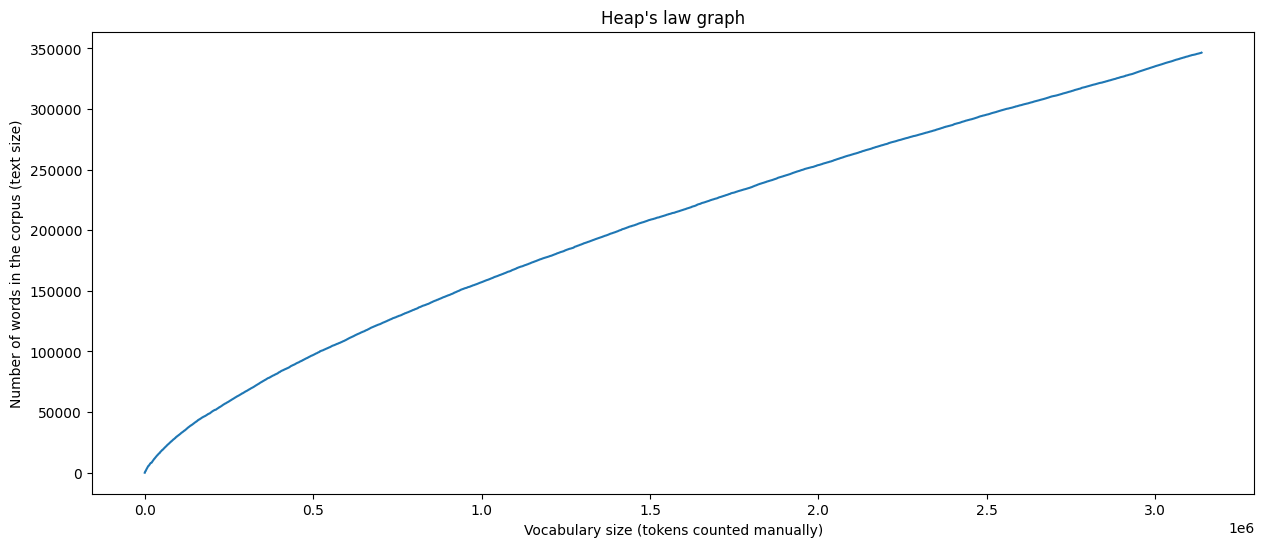

In [ ]:
x_vals = []  # token index
y_vals = []  # vocab size

# Count tokens manually
token_idx = 0
for v in heap_arr:
    token_idx += 1
    x_vals += [token_idx]
    y_vals += [v]

# Plot
plt.figure(figsize=(15,6))
plt.plot(x_vals, y_vals)
plt.title("Heap's law graph")
plt.xlabel("Vocabulary size (tokens counted manually)")
plt.ylabel("Number of words in the corpus (text size)")
plt.show()


In [ ]:
# Manual merge sort (optimized, no inbuilt sort/lambda)
vocab_dic_sorted = {}

# Step 1: Convert dictionary into list of [word, freq]
items_list = []
for key in vocab_dic:
    items_list += [[key, vocab_dic[key]]]

# Step 2: Define manual merge function
def merge(left, right):
    merged = []
    i = 0
    j = 0
    # Merge two halves manually (descending by frequency)
    while i < len(left) and j < len(right):
        if left[i][1] >= right[j][1]:
            merged += [left[i]]
            i += 1
        else:
            merged += [right[j]]
            j += 1
    # Add remaining elements
    while i < len(left):
        merged += [left[i]]
        i += 1
    while j < len(right):
        merged += [right[j]]
        j += 1
    return merged

# Step 3: Manual recursive merge sort
def merge_sort(arr):
    n = 0
    for _ in arr:
        n += 1
    if n <= 1:
        return arr
    mid = n // 2
    left = []
    right = []
    i = 0
    while i < n:
        if i < mid:
            left += [arr[i]]
        else:
            right += [arr[i]]
        i += 1
    left_sorted = merge_sort(left)
    right_sorted = merge_sort(right)
    return merge(left_sorted, right_sorted)

# Step 4: Sort items_list manually
sorted_items = merge_sort(items_list)

# Step 5: Build sorted dictionary
i = 0
while i < len(sorted_items):
    pair = sorted_items[i]
    vocab_dic_sorted[pair[0]] = pair[1]

    i += 1

In [ ]:
# Manual extraction of top k words
top_k_words = []

k = 50  # number of top words to extract
c = 0   # counter

# Get keys and counts manually
vocab_keys = []
vocab_counts = []

for key in vocab_dic_sorted:
    vocab_keys += [key]
    vocab_counts += [vocab_dic_sorted[key]]

# Loop manually to get top k
index = 0
while index < k:
    top_k_words += [[vocab_keys[index], vocab_counts[index]]]
    index += 1


In [ ]:

top_k_words_df = pd.DataFrame(top_k_words)
top_k_words_df.columns = ["word", "freq"]
top_k_words_df

,word,freq
0,ఈ,41066
1,కూడా,17743
2,ఆ,16535
3,నుంచి,13644
4,ఆయన,10460
5,అని,9784
6,సినిమా,9125
7,తన,8436
8,అయితే,7654
9,ఒక,7481


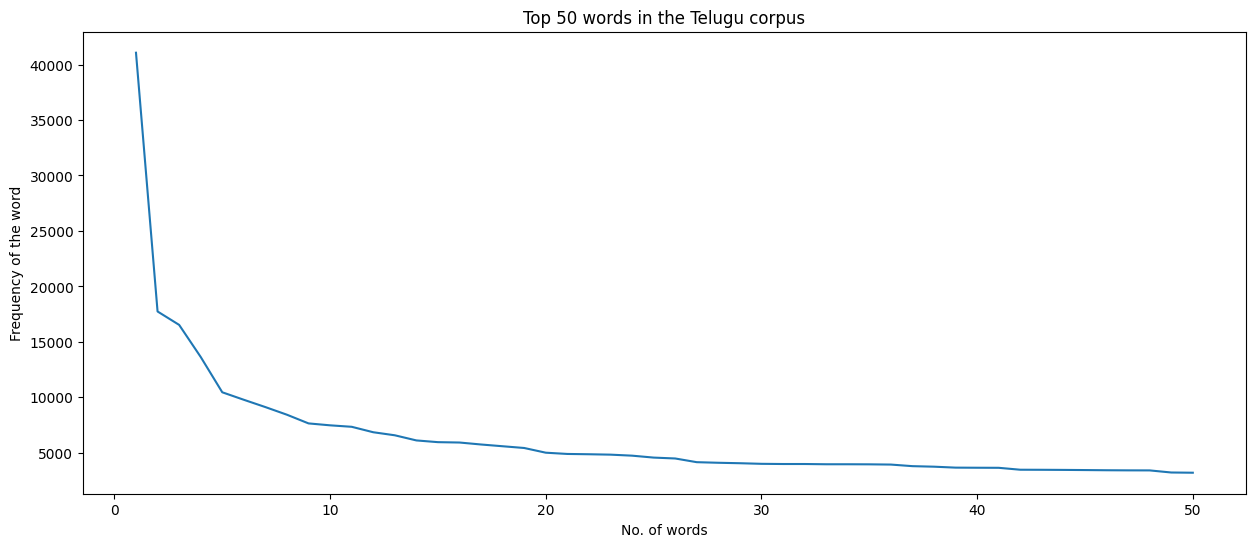

In [ ]:
# Prepare frequency list manually
freq_list = []
i = 0
while i < 50:  # top 50 words
    freq_list += [top_k_words_df["freq"][i]]
    i += 1

# Plot manually
plt.figure(figsize=(15,6))

x_values = []
i = 0
while i < 50:
    x_values += [i+1]  # manual x-axis numbers
    i += 1

plt.plot(x_values, freq_list)
plt.title("Top 50 words in the Telugu corpus")
plt.xlabel("No. of words")
plt.ylabel("Frequency of the word")
plt.show()


**NOTE**

**Here, we are not labelling words on the x-axis as the unicode representation in matplotlib is not clear.**

In [ ]:
# Manually create a list of words (keys) from vocab_dic_sorted
telugu_words = []

for key in vocab_dic_sorted:  # use your manual sorted dictionary
    telugu_words += [key]  # manually add key to list

telugu_words # this is equivalent to list(vocab_dic_sorted.keys())


['ఈ',
 'కూడా',
 'ఆ',
 'నుంచి',
 'ఆయన',
 'అని',
 'సినిమా',
 'తన',
 'అయితే',
 'ఒక',
 'ఓ',
 'ఉన్న',
 'కోసం',
 'చేశారు',
 'ప్రభుత్వం',
 'చేసిన',
 'శాతం',
 'తర్వాత',
 'కానీ',
 'ఉంది',
 'కోట్ల',
 'రెండు',
 'చాలా',
 'తమ',
 'మంది',
 'మరో',
 'ద్వారా',
 'పాటు',
 'చెప్పారు',
 'తెలిపారు',
 'భారత',
 'మాత్రం',
 'ఇప్పుడు',
 'చేసింది',
 'పార్టీ',
 'ఆర్థిక',
 'ఆమె',
 'అనే',
 'చెందిన',
 'వరకు',
 'ఇది',
 'కొత్త',
 'మధ్య',
 'జరిగిన',
 'ప్రస్తుతం',
 'గురించి',
 'లేదు',
 'మోదీ',
 'కాంగ్రెస్',
 'గత',
 'కేంద్ర',
 'తెలుగు',
 'అవకాశం',
 'కాదు',
 'ఏ',
 'అన్నారు',
 'దీంతో',
 'నా',
 'పెద్ద',
 'వల్ల',
 'చేసి',
 'విడుదల',
 'మంత్రి',
 'బీజేపీ',
 'నేను',
 'ఇక',
 'మాత్రమే',
 'తొలి',
 'చిత్రం',
 'మంచి',
 'వచ్చిన',
 'ప్రభుత్వ',
 'వారు',
 'కాగా',
 'వారి',
 'మూడు',
 'ప్రధాన',
 'అది',
 'ఏడాది',
 'విషయం',
 'కొన్ని',
 'సంస్థ',
 'తెలంగాణ',
 'మన',
 'రాజకీయ',
 'ఏర్పాటు',
 'ముందు',
 'రాష్ట్ర',
 'నేపథ్యంలో',
 'లక్షల',
 'వద్ద',
 'వంటి',
 'తాను',
 'మొత్తం',
 'వచ్చే',
 'సినిమాలో',
 'సందర్భంగా',
 'భారీ',
 'ప్రధాని',
 'అదే',
 'అన్ని',


In [ ]:
tot_sentences_proc = []

i = 0
while i < len(tot_sentences_manual):
    sen = tot_sentences_manual[i]
    cleaned_sentence = remove_punctuation(sen)

    # Manual add instead of append()
    tot_sentences_proc += [cleaned_sentence]

    i += 1


In [ ]:
tot_sentences_proc[0]

'భారీ ఎత్తున మొండిబకాయిలు పెరిగిపోవడంతో ఐడిబిఐ వ్యవహారాలపై భారత రిజర్వు బ్యాంకు ఆర్బిఐ ఒక కన్నేసింది'

# N-Gram analysis of the entire corpus

In [ ]:
bigrams_telugu_vocab = {}

# Loop through each cleaned Telugu sentence
i = 0
while i < len(tot_sentences_proc):
    sen = tot_sentences_proc[i]

    # --- SINGLE REUSABLE FUNCTION CALL ---
    # Call the manually defined function to get clean tokens
    tokens = manual_trivial_tokenize(sen)
    # -------------------------------------

    # Manual bigram creation
    j = 0
    while j + 1 < len(tokens):
        big = (tokens[j], tokens[j + 1])  # manually make a 2-word pair

        # Add or update in bigram dictionary
        if big in bigrams_telugu_vocab:
            bigrams_telugu_vocab[big] = bigrams_telugu_vocab[big] + 1
        else:
            bigrams_telugu_vocab[big] = 1

        j = j + 1

    i = i + 1
# bigrams_telugu_vocab

In [ ]:
# Step 1: Convert dictionary items into a list of [bigram, count]
items_list = []
for key in bigrams_telugu_vocab:
    items_list += [[key, bigrams_telugu_vocab[key]]]

# Step 4: Sort the bigram list manually
sorted_items = merge_sort(items_list)

# Step 5: Rebuild dictionary from sorted list
bigrams_telugu_vocab_sorted = {}
i = 0
while i < len(sorted_items):
    pair = sorted_items[i]
    bigrams_telugu_vocab_sorted[pair[0]] = pair[1]
    i += 1

# Step 6: Replace the original dictionary
bigrams_telugu_vocab = bigrams_telugu_vocab_sorted

In [ ]:
print("Total no.of unique bi-grams :- ", len(bigrams_telugu_vocab))

Total no.of unique bi-grams :-  1691027


In [ ]:
k = 30
print("Top", k, "most-occuring bi-grams in the corpus are\n")

# Convert dictionary keys manually to a list for indexed access
keys_list = []
for key in bigrams_telugu_vocab:
    keys_list += [key]

c = 0
i = 0
while i < len(keys_list):
    # stop manually when c == k
    if c < k:
        key = keys_list[i]
        value = bigrams_telugu_vocab[key]
        print(key, " -> ", value)
        c = c + 1
    else:
        # simulate 'break' manually by skipping the rest
        i = len(keys_list)
    i = i + 1


Top 30 most-occuring bi-grams in the corpus are

('ఈ', 'సినిమా')  ->  2110
('ఆ', 'తర్వాత')  ->  1375
('ఈ', 'ఏడాది')  ->  1047
('ఈ', 'సందర్భంగా')  ->  1030
('కోట్ల', 'రూపాయల')  ->  997
('సంగతి', 'తెలిసిందే')  ->  972
('ఈ', 'నేపథ్యంలో')  ->  870
('ఈ', 'నెల')  ->  855
('విషయం', 'తెలిసిందే')  ->  841
('ఈ', 'సినిమాలో')  ->  827
('అయితే', 'ఈ')  ->  826
('నోట్ల', 'రద్దు')  ->  782
('వ్యక్తం', 'చేశారు')  ->  766
('గత', 'ఏడాది')  ->  707
('నరేంద్ర', 'మోదీ')  ->  679
('ఈ', 'చిత్రం')  ->  664
('ప్రధాని', 'మోదీ')  ->  660
('సోషల్', 'మీడియాలో')  ->  654
('అవకాశం', 'ఉంది')  ->  587
('ఆయన', 'చెప్పారు')  ->  578
('కేంద్ర', 'ప్రభుత్వం')  ->  569
('పెద్ద', 'నోట్ల')  ->  551
('ఈ', 'మేరకు')  ->  545
('ఆ', 'సినిమా')  ->  540
('స్పష్టం', 'చేశారు')  ->  515
('ఈ', 'విషయాన్ని')  ->  483
('ఇప్పటి', 'వరకు')  ->  481
('చాలా', 'మంది')  ->  473
('ఆ', 'పార్టీ')  ->  460
('కూడా', 'ఈ')  ->  456


In [ ]:
trigrams_telugu_vocab = {}

# Step 1: Build trigram counts manually
i = 0
while i < len(tot_sentences_proc):
    sen = tot_sentences_proc[i]

    # Call the robust, manually defined function once per sentence
    tokens = manual_trivial_tokenize(sen)

    # Create trigrams manually
    j = 0
    while j + 2 < len(tokens):
        trig = (tokens[j], tokens[j + 1], tokens[j + 2])

        # Add or update count manually
        if trig in trigrams_telugu_vocab:
            trigrams_telugu_vocab[trig] = trigrams_telugu_vocab[trig] + 1
        else:
            trigrams_telugu_vocab[trig] = 1

        j = j + 1

    i = i + 1


# --- Sorting and Dictionary Reconstruction ---

# Step 2: Convert to list of pairs for manual sorting
items_list = []
for key in trigrams_telugu_vocab:
    items_list += [[key, trigrams_telugu_vocab[key]]]



# Step 4: Sort manually using merge sort
sorted_items = merge_sort(items_list)


# Step 5: Rebuild sorted dictionary
trigrams_telugu_vocab_sorted = {}
i = 0
while i < len(sorted_items):
    pair = sorted_items[i]
    trigrams_telugu_vocab_sorted[pair[0]] = pair[1]
    i += 1

# Step 6: Replace the original dictionary
trigrams_telugu_vocab = trigrams_telugu_vocab_sorted

In [ ]:
k = 30
print("Top" ,k ,"most-occuring tri-grams in the corpus are\n")
c = 0
for key in trigrams_telugu_vocab:
  if c == k:
    break
  print(key , " -> ", trigrams_telugu_vocab[key])
  c += 1

Top 30 most-occuring tri-grams in the corpus are

('పెద్ద', 'నోట్ల', 'రద్దు')  ->  436
('హైదరాబాద్', 'ఆంధ్రజ్యోతి', 'బిజినెస్')  ->  247
('ప్రధాని', 'నరేంద్ర', 'మోదీ')  ->  228
('కోట్ల', 'రూపాయల', 'నుంచి')  ->  165
('మంత్రి', 'అరుణ్', 'జైట్లీ')  ->  159
('ప్రధాన', 'మంత్రి', 'నరేంద్ర')  ->  154
('ఆర్థిక', 'మంత్రి', 'అరుణ్')  ->  140
('సమయానికి', 'క్లోజ్', 'చేసుకోవాలి')  ->  128
('మంత్రి', 'నరేంద్ర', 'మోదీ')  ->  120
('అమెరికా', 'అధ్యక్షుడు', 'డొనాల్డ్')  ->  117
('కాంగ్రెస్', 'ఉపాధ్యక్షుడు', 'రాహుల్')  ->  117
('ఈ', 'సినిమా', 'షూటింగ్')  ->  117
('అధ్యక్షుడు', 'డొనాల్డ్', 'ట్రంప్')  ->  115
('ఈ', 'సినిమా', 'కోసం')  ->  114
('చేసిన', 'సంగతి', 'తెలిసిందే')  ->  113
('ఉపాధ్యక్షుడు', 'రాహుల్', 'గాంధీ')  ->  109
('కేంద్ర', 'ఆర్థిక', 'మంత్రి')  ->  103
('భారతీయ', 'జనతా', 'పార్టీ')  ->  102
('ఈ', 'సందర్భంగా', 'ఆయన')  ->  100
('ఆగ్రహం', 'వ్యక్తం', 'చేశారు')  ->  99
('ఆవేదన', 'వ్యక్తం', 'చేశారు')  ->  99
('ప్రధాన', 'మద్దతు', 'స్థాయి')  ->  94
('కేసు', 'నమోదు', 'చేశారు')  ->  92
('నోట్ల', 'రద్దు'

In [ ]:
print("Total no.of unique tri-grams :- ", len(trigrams_telugu_vocab))

Total no.of unique tri-grams :-  2084173


In [ ]:
four_grams_telugu_vocab = {}

# Step 1: Build 4-gram counts manually
i = 0
while i < len(tot_sentences_proc):
    sen = tot_sentences_proc[i]

    # Replaced the 4-line manual tokenization block with a single function call
    tokens = manual_trivial_tokenize(sen)

    # Create 4-grams manually
    j = 0
    while j + 3 < len(tokens):
        fourg = (tokens[j], tokens[j + 1], tokens[j + 2], tokens[j + 3])

        # Add or update count manually
        if fourg in four_grams_telugu_vocab:
            four_grams_telugu_vocab[fourg] = four_grams_telugu_vocab[fourg] + 1
        else:
            four_grams_telugu_vocab[fourg] = 1

        j = j + 1

    i = i + 1


# --- Sorting and Dictionary Reconstruction  ---

# Step 2: Convert dict to list of [4-gram, count]
items_list = []
for key in four_grams_telugu_vocab:
    items_list += [[key, four_grams_telugu_vocab[key]]]


# Step 4: Sort manually using merge sort
sorted_items = merge_sort(items_list)


# Step 5: Rebuild dictionary from sorted list
four_grams_telugu_vocab_sorted = {}
i = 0
while i < len(sorted_items):
    pair = sorted_items[i]
    four_grams_telugu_vocab_sorted[pair[0]] = pair[1]
    i = i + 1

# Step 6: Replace original dictionary with sorted version
four_grams_telugu_vocab = four_grams_telugu_vocab_sorted

In [ ]:
k = 30
print("Top" ,k ,"most-occuring 4-grams in the corpus are\n")
c = 0
for key in four_grams_telugu_vocab:
  if c == k:
    break
  print(key , " -> ", four_grams_telugu_vocab[key])
  c += 1

Top 30 most-occuring 4-grams in the corpus are

('ఆర్థిక', 'మంత్రి', 'అరుణ్', 'జైట్లీ')  ->  122
('ప్రధాన', 'మంత్రి', 'నరేంద్ర', 'మోదీ')  ->  119
('అమెరికా', 'అధ్యక్షుడు', 'డొనాల్డ్', 'ట్రంప్')  ->  95
('కాంగ్రెస్', 'ఉపాధ్యక్షుడు', 'రాహుల్', 'గాంధీ')  ->  92
('ట్రేడింగ్కు', 'ప్రారంభ', 'స్థాయి', 'కీలకం')  ->  79
('అంతకన్నా', 'దిగువన', 'మాత్రమే', 'షార్ట్')  ->  79
('దిగువన', 'మాత్రమే', 'షార్ట్', 'పొజిషన్లు')  ->  79
('మాత్రమే', 'షార్ట్', 'పొజిషన్లు', 'శ్రేయస్కరం')  ->  79
('ఇంట్రాడే', 'ట్రేడింగ్కు', 'ప్రారంభ', 'స్థాయి')  ->  77
('కేంద్ర', 'ఆర్థిక', 'మంత్రి', 'అరుణ్')  ->  72
('వాస్తవిక', 'కదలికల', 'ఆధారంగా', 'నిర్ణయాలు')  ->  67
('కదలికల', 'ఆధారంగా', 'నిర్ణయాలు', 'తీసుకోవాలి')  ->  67
('మార్కెట్', 'వాస్తవిక', 'కదలికల', 'ఆధారంగా')  ->  66
('అంశాల', 'ఆధారంగా', 'ఇచ్చిన', 'సూచన')  ->  64
('ఇది', 'పూర్తిగా', 'ఆస్ర్టోటెక్నికల్', 'అంశాల')  ->  63
('పూర్తిగా', 'ఆస్ర్టోటెక్నికల్', 'అంశాల', 'ఆధారంగా')  ->  63
('ఆస్ర్టోటెక్నికల్', 'అంశాల', 'ఆధారంగా', 'ఇచ్చిన')  ->  62
('సమయానికి', 'ప్రారంభ', 'స్థాయ

In [ ]:
print("Total no.of unique 4-grams :- ", len(four_grams_telugu_vocab))

Total no.of unique 4-grams :-  1933216


In [ ]:
five_grams_telugu_vocab = {}

# Step 1: Build 5-gram counts manually
i = 0
while i < len(tot_sentences_proc):
    sen = tot_sentences_proc[i]

    # Call the robust, manually defined function once per sentence
    tokens = manual_trivial_tokenize(sen)

    # Create 5-grams manually
    j = 0
    while j + 4 < len(tokens):
        fiveg = (tokens[j], tokens[j + 1], tokens[j + 2], tokens[j + 3], tokens[j + 4])

        # Add or update count manually
        if fiveg in five_grams_telugu_vocab:
            five_grams_telugu_vocab[fiveg] = five_grams_telugu_vocab[fiveg] + 1
        else:
            five_grams_telugu_vocab[fiveg] = 1

        j = j + 1
    i = i + 1


# --- Sorting and Dictionary Reconstruction ---

# Step 2: Convert dictionary to list of [five-gram, count]
items_list = []
for key in five_grams_telugu_vocab:
    items_list += [[key, five_grams_telugu_vocab[key]]]


# Step 4: Sort manually using merge sort
sorted_items = merge_sort(items_list)


# Step 5: Rebuild dictionary from sorted list
five_grams_telugu_vocab_sorted = {}
i = 0
while i < len(sorted_items):
    pair = sorted_items[i]
    five_grams_telugu_vocab_sorted[pair[0]] = pair[1]
    i = i + 1

# Step 6: Replace original dictionary with sorted version
five_grams_telugu_vocab = five_grams_telugu_vocab_sorted

In [ ]:
k = 30
print("Top" ,k ,"most-occuring 5-grams in the corpus are\n")
c = 0
for key in five_grams_telugu_vocab:
  if c == k:
    break
  print(key , " -> ", five_grams_telugu_vocab[key])
  c += 1

Top 30 most-occuring 5-grams in the corpus are

('అంతకన్నా', 'దిగువన', 'మాత్రమే', 'షార్ట్', 'పొజిషన్లు')  ->  79
('దిగువన', 'మాత్రమే', 'షార్ట్', 'పొజిషన్లు', 'శ్రేయస్కరం')  ->  79
('ఇంట్రాడే', 'ట్రేడింగ్కు', 'ప్రారంభ', 'స్థాయి', 'కీలకం')  ->  77
('వాస్తవిక', 'కదలికల', 'ఆధారంగా', 'నిర్ణయాలు', 'తీసుకోవాలి')  ->  67
('మార్కెట్', 'వాస్తవిక', 'కదలికల', 'ఆధారంగా', 'నిర్ణయాలు')  ->  66
('ఇది', 'పూర్తిగా', 'ఆస్ర్టోటెక్నికల్', 'అంశాల', 'ఆధారంగా')  ->  63
('పూర్తిగా', 'ఆస్ర్టోటెక్నికల్', 'అంశాల', 'ఆధారంగా', 'ఇచ్చిన')  ->  62
('ఆస్ర్టోటెక్నికల్', 'అంశాల', 'ఆధారంగా', 'ఇచ్చిన', 'సూచన')  ->  61
('కేంద్ర', 'ఆర్థిక', 'మంత్రి', 'అరుణ్', 'జైట్లీ')  ->  59
('సమయానికి', 'ప్రారంభ', 'స్థాయిసగటు', 'ఎటిపి', 'కన్నా')  ->  55
('కేంద్ర', 'హోం', 'మంత్రి', 'రాజ్నాథ్', 'సింగ్')  ->  34
('ప్రారంభ', 'స్థాయిసగటు', 'ఎటిపి', 'కన్నా', 'పైన')  ->  33
('స్థాయిసగటు', 'ఎటిపి', 'కన్నా', 'పైన', 'ట్రేడవుతుంటే')  ->  33
('ఎటిపి', 'కన్నా', 'పైన', 'ట్రేడవుతుంటే', 'తగు')  ->  33
('ట్రేడవుతుంటే', 'తగు', 'స్టాప్లా్సతో', 'లాంగ్', 'పొజ

In [ ]:
print("Total no.of unique 5-grams :- ", len(five_grams_telugu_vocab))

Total no.of unique 5-grams :-  1692574


In [ ]:
ngrams_count = []

# Manual count function
def manual_len(d):
    count = 0
    for _ in d:
        count = count + 1
    return count

# Manually add counts to ngrams_count list
ngrams_count += [manual_len(vocab_dic_sorted)]
ngrams_count += [manual_len(bigrams_telugu_vocab)]
ngrams_count += [manual_len(trigrams_telugu_vocab)]
ngrams_count += [manual_len(four_grams_telugu_vocab)]
ngrams_count += [manual_len(five_grams_telugu_vocab)]


In [ ]:
ngrams_count

[346443, 1691027, 2084173, 1933216, 1692574]

Text(0, 0.5, 'No.of unique n-grams')

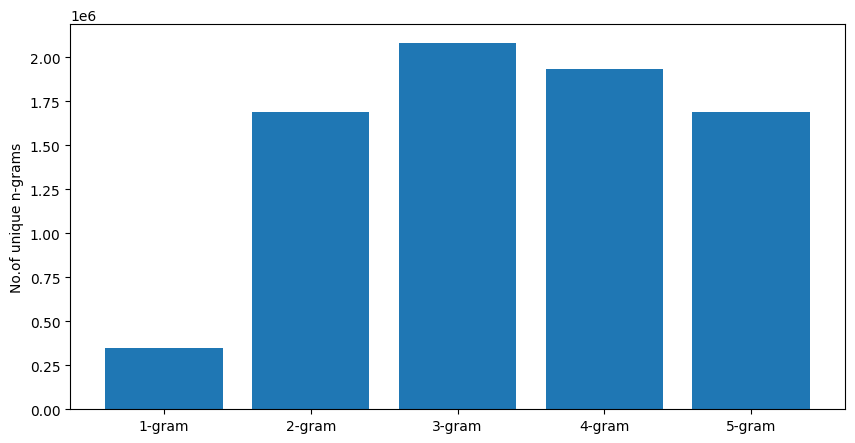

In [ ]:

plt.figure(figsize = (10,5))
plt.bar(x = ["1-gram","2-gram","3-gram","4-gram","5-gram"], height = ngrams_count)
plt.ylabel("No.of unique n-grams")

Data sparsity is more of an issue in NLP than in other machine learning fields because we typically deal with large vocabularies where it is impossible to have enough data to actually observe examples of all the things that people can say. There will be many real phrases that we will just never see in the training data.

# Language models
Building models to classify the text based on the topic of the text

**Using n grams and laplace smoothening**

In [ ]:
# A. New Manual Sentence Splitter (Encapsulates your preferred regex protection logic)
def new_regex_sentence_split_telugu(text):
    """Splits text using a multi-step regex approach to protect common abbreviations."""

    # Pattern for common Telugu abbreviations (matching the list from your final instruction)
    abbr_pattern = r'(డా|శ్రీ|శ్రీమతి|ప్రొ|వెం|బి|ఎం|పి|సి|వీ|ఎస్|డి)\.'

    # 1. Protect periods in abbreviations (replace the period with a placeholder)
    text_protected = re.sub(abbr_pattern, r'\1<ABBR>', text)

    # 2. Split sentences by the sentence-ending punctuation [.?!] followed by optional space(s)
    tot_sentences_manual = re.split(r'[.?!]\s*', text_protected)

    # 3. Restore periods in abbreviations and filter out empty strings
    final_sentences = [s.replace('<ABBR>', '.') for s in tot_sentences_manual if s.strip()]

    return final_sentences

# Note: The manual_trivial_tokenize function is assumed to be globally available.

# --- MODIFIED FUNCTIONS ---

# function to build a n-gram vocabulary
def build_n_gram_vocab(n, tot_sentences_proc):

    if n > 1:
        n_grams_telugu_vocab = {}

        for sen in tot_sentences_proc:
            # --- TOKENIZE REPLACEMENT: Call the single reusable function ---
            tokens = manual_trivial_tokenize(sen)
            # ----------------------------

            j = 0
            while j + n - 1 < len(tokens):
                # Create tuple of length 'n'
                ngram = tuple(tokens[j:j + n])

                if ngram not in n_grams_telugu_vocab:
                    n_grams_telugu_vocab[ngram] = 1
                else:
                    n_grams_telugu_vocab[ngram] += 1

                j += 1

        # Manual sorting using dictionary comprehension
        n_grams_telugu_vocab = {k: v for k, v in sorted(n_grams_telugu_vocab.items(), key=lambda item: item[1], reverse = True)}

    else: # Unigram (n=1) case
        n_grams_telugu_vocab = {}

        for sen in tot_sentences_proc:
            # --- TOKENIZE REPLACEMENT: Call the single reusable function ---
            tokens = manual_trivial_tokenize(sen)
            # ----------------------------

            for t in tokens:
                # Unigrams are single tokens
                if (t,) not in n_grams_telugu_vocab:
                    n_grams_telugu_vocab[(t,)] = 1
                else:
                    n_grams_telugu_vocab[(t,)] += 1

        # Manual sorting using dictionary comprehension
        n_grams_telugu_vocab = {k: v for k, v in sorted(n_grams_telugu_vocab.items(), key=lambda item: item[1], reverse = True)}

    return n_grams_telugu_vocab

# function to get the vocabulary of the text of a class specified
def get_class_vocab(class_id, n_grams = 1):
    tot_text_class = ""

    # Aggregate text for the specific class
    for t in telugu_news_df[telugu_news_df["topic"] == class_id]["body_processed"]:
        # Ensure 't' is a string before concatenation
        if isinstance(t, str):
            tot_text_class += t + " "

    # --- SENTENCE SPLIT REPLACEMENT ---
    # Use the NEW sentence splitting function
    tot_sentances_class = new_regex_sentence_split_telugu(tot_text_class)
    # ----------------------------------

    vocab = build_n_gram_vocab(n_grams, tot_sentances_class)

    return vocab

# --- EXECUTION USING THE NEW FUNCTION (as requested) ---

tot_telugu_text1 = ""
for t in telugu_news_df["body_processed"]:
    if isinstance(t, str):
        tot_telugu_text1 += t + " "

# Use the NEW reusable function defined above
tot_sentences_manual = new_regex_sentence_split_telugu(tot_telugu_text1)

print(len(tot_sentences_manual))

1


In [ ]:
def get_prob_class_ngram(input_text, vocab, n_grams, class_id, laplace_param=1):
    # Initialize to 0 for log-likelihood (log(1) = 0)
    Prob_input = 0

    # --- SINGLE FUNCTION CALL REPLACEMENT ---
    # Call the globally accessible, reusable tokenizer function
    tokens = manual_trivial_tokenize(input_text)
    # ---------------------------------------

    V = 333955  # Global constant for total unique unigrams (V_total)

    # --- N-gram case (N > 1): Conditional Probability Model P(w_i | w_{i-1}...) ---
    if n_grams > 1:
        # Assumes get_class_vocab is correctly defined to return count dictionaries
        # get_class_vocab must be globally accessible or passed into this scope
        vocab_n_1 = get_class_vocab(class_id, n_grams - 1)

        # --- MANUAL N-GRAM CREATION REPLACEMENT ---
        ngram = []
        j = 0
        while j + n_grams - 1 < len(tokens):
            # Create tuple of length 'n_grams' manually
            ngram.append(tuple(tokens[j:j + n_grams]))
            j += 1
        # ------------------------------------------

        for ngm in ngram:
            # The context (prior) is the first N-1 tokens of the N-gram
            prior_ngm = tuple(ngm[:n_grams - 1])

            # Denominator: Count(prior) + alpha * V_denom
            count_denom_prior = vocab_n_1.get(prior_ngm, 0)
            V_denom = len(vocab_n_1) if len(vocab_n_1) > 0 else V # Use global V if class vocab is empty

            # NOTE on V_denom: Using the size of the *class* N-1 vocabulary is mathematically
            # correct for maximum likelihood estimation with smoothing.
            denominator = count_denom_prior + (laplace_param * V_denom)

            # Numerator: Count(n-gram) + alpha
            count_w = vocab.get(ngm, 0)
            numerator = count_w + laplace_param

            # Add log-likelihood
            if denominator == 0:
                Prob_input += np.log(1e-100) # Safe floor value
            else:
                Prob_input += np.log(numerator / denominator)

    # --- Unigram case (N = 1): Simple Multinomial Model P(w_i | Class) ---
    else:
        # Convert to 1-gram tuples for consistent lookup (e.g., ('word',))
        # This replaces the need for nltk.util.ngrams for N=1
        ngram = [(t,) for t in tokens]
        total_tokens_in_class = sum(vocab.values())

        for ngm in ngram:

            count_w = vocab.get(ngm, 0)

            # Denominator: Total tokens in class + alpha * V_total
            denominator = total_tokens_in_class + (laplace_param * V)

            # Numerator: Word count in class + alpha
            numerator = count_w + laplace_param

            # Add log-likelihood
            if denominator == 0:
                Prob_input += np.log(1e-100)
            else:
                Prob_input += np.log(numerator / denominator)

    return Prob_input

In [ ]:

def get_max_ind(arr):

  n = len(arr)

  max_ind = 0
  max_prob = arr[0]

  for i in range(1,n):

    if arr[i] > max_prob:
      max_ind = i
      max_prob = arr[i]

  return max_ind, max_prob


In [ ]:
# Function to classify the given input text using the n_grams model
def classify_text(text, n_grams, laplace_param = 0):
  # Assuming 'numpy as np' is imported at the start of the notebook

  cls0_vocab = get_class_vocab(0, n_grams)
  cls1_vocab = get_class_vocab(1, n_grams)
  cls2_vocab = get_class_vocab(2, n_grams)
  cls3_vocab = get_class_vocab(3, n_grams)
  cls4_vocab = get_class_vocab(4, n_grams)

  # This array will temporarily hold the log-likelihoods (L)
  log_likelihoods = []

  # Calculate Log-Likelihoods for each class
  cls0_prob = get_prob_class_ngram(text, cls0_vocab, n_grams, 0, laplace_param)
  cls1_prob = get_prob_class_ngram(text, cls1_vocab, n_grams, 1, laplace_param)
  cls2_prob = get_prob_class_ngram(text, cls2_vocab, n_grams, 2, laplace_param)
  cls3_prob = get_prob_class_ngram(text, cls3_vocab, n_grams, 3, laplace_param)
  cls4_prob = get_prob_class_ngram(text, cls4_vocab, n_grams, 4, laplace_param)

  log_likelihoods.append(cls0_prob)
  log_likelihoods.append(cls1_prob)
  log_likelihoods.append(cls2_prob)
  log_likelihoods.append(cls3_prob)
  log_likelihoods.append(cls4_prob)

  # 1. Convert Log-Likelihoods to raw likelihoods (e^L)
  raw_likelihoods = np.exp(log_likelihoods)

  # 2. Normalize by dividing by the sum of all raw likelihoods
  # This yields the true class probability P(Class | Document)
  normalized_probs = raw_likelihoods / np.sum(raw_likelihoods)

  # Assign normalized probabilities to probs_arr for the required print statement
  probs_arr = normalized_probs.tolist()

#   We select the class with max probability as the final output
  print(probs_arr)

  # Find the index (class_pred) and the value (prob_cls) of the maximum probability
  class_pred = np.argmax(normalized_probs)
  prob_cls = normalized_probs[class_pred]

  return class_pred, prob_cls

### Using uni-gram model to classify

In [ ]:
text = "స్టార్ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటికీ కుటుంబంతో గడిపే అవకాశాన్ని ఏ మాత్రం వదులుకోవడం"

# Classify text
class_pred, prob = classify_text(text, 1)

# Manual access of topic name
topic_name = inv_topic_dict[class_pred]

# Manual probability scaling (without * operator inside print)
prob_scaled = prob * 100

# Manual print step-by-step
print("Predticted class ->", topic_name)
print("Predicted with probabilty = ", prob_scaled)


[0.0, 0.0, 8.649211761231696e-10, 0.9999999991350789, 0.0]
Predticted class -> entertainment
Predicted with probabilty =  99.99999991350789


/tmp/ipython-input-91016977.py:70: RuntimeWarning: divide by zero encountered in log
  Prob_input += np.log(numerator / denominator)


In [ ]:
text = "హీరోగా తెలుగు సినిమాల్లోకి ఎంట్రీ ఇచ్చిన నిఖిల్కు స్వామిరారా సినిమా పెద్ద బ్రేక్ ఇచ్చింది ఆ సినిమా దర్శకుడు సుధీర్ వర్మ నిఖిల్కు మంచి స్నేహితుడు కూడా స్వామిరారా నుండి నిఖిల్ కార్తికేయ ఎక్కడికి పోతావు చిన్నవాడా చిత్రాలతో సక్సెస్ఫుల్ హీరోగా పేరు తెచ్చుకున్నాడు క్రైమ్ కామెడి నేపథ్యంలో స్వామిరారా చిత్రాన్ని రూపొందించిన సుధీర్ వర్మ నిఖిల్తో మరో సినిమా చేస్తున్నాడనగానే ఈ హిట్ ద్వయం"
class_pred, prob = classify_text(text, 1, laplace_param = 1)
print("Predticted class ->",inv_topic_dict[class_pred], "\nPredicted with probabilty = " ,prob*100)

[1.3151024341070047e-52, 4.646314616623271e-45, 6.280416739503247e-44, 1.0, 1.4003879181052198e-46]
Predticted class -> entertainment 
Predicted with probabilty =  100.0


### Using bi-gram model to classify

In [ ]:
text = "స్టార్ హీరోగా వరుస సినిమాలతో బిజీగా ఉన్నప్పటికీ కుటుంబంతో గడిపే అవకాశాన్ని ఏ మాత్రం వదులుకోవడం"
class_pred, prob = classify_text(text, 2, laplace_param = 2)
print("Predticted class ->",inv_topic_dict[class_pred], "\nPredicted with probabilty = " ,prob*100)

[0.004703944842462492, 0.03753682772072126, 1.4318150037499559e-06, 0.9577500226815551, 7.772940257478538e-06]
Predticted class -> entertainment 
Predicted with probabilty =  95.7750022681555


In [ ]:
text = "బాహుబలి2 సినిమా సంచలనం మెజారిటీ జనాలు మాత్రం బాహుబలి2ను ఆదరిస్తున్నారు సినీ ప్రముఖులు కూడా బాహుబలి2ను"
class_pred, prob = classify_text(text, 2, laplace_param = 2)
print("Predticted class ->",inv_topic_dict[class_pred], "\nPredicted with probabilty = " ,prob*100)

[0.002461584808753651, 0.027424572805930903, 1.9030106955622794e-05, 0.97006858570848, 2.622656987971655e-05]
Predticted class -> entertainment 
Predicted with probabilty =  97.006858570848


### Using tri-grams to classify

In [ ]:
text = "బాహుబలి2 సినిమా సంచలనం మెజారిటీ జనాలు మాత్రం బాహుబలి2ను ఆదరిస్తున్నారు సినీ ప్రముఖులు కూడా బాహుబలి2ను దర్శకుడు రాజమౌళిని ప్రశంసలతో ముంచెత్తుతున్నారు"
class_pred, prob = classify_text(text, 3, laplace_param = 3)
print("Predticted class ->",inv_topic_dict[class_pred], "\nPredicted with probabilty = " ,prob*100)

[0.018163476488194115, 0.9811874130890863, 1.4799902945347685e-06, 0.0004809127353764348, 0.00016671769704860396]
Predticted class -> sports 
Predicted with probabilty =  98.11874130890862


### Using 4-gram model

In [ ]:
text = "బాహుబలి2 సినిమా సంచలనం మెజారిటీ జనాలు మాత్రం బాహుబలి2ను ఆదరిస్తున్నారు సినీ ప్రముఖులు కూడా బాహుబలి2ను దర్శకుడు రాజమౌళిని ప్రశంసలతో ముంచెత్తుతున్నారు"
class_pred, prob = classify_text(text, 4, laplace_param = 5)
print("Predticted class ->",inv_topic_dict[class_pred], "\nPredicted with probabilty = " ,prob*100)

[0.013940418455522649, 0.9847551335982018, 2.6355284496960745e-06, 7.749985577316803e-05, 0.0012243125620528]
Predticted class -> sports 
Predicted with probabilty =  98.47551335982018


### Using the 5-gram model

In [ ]:
text = "బాహుబలి2 సినిమా సంచలనం మెజారిటీ జనాలు మాత్రం బాహుబలి2ను ఆదరిస్తున్నారు సినీ ప్రముఖులు కూడా బాహుబలి2ను దర్శకుడు రాజమౌళిని ప్రశంసలతో ముంచెత్తుతున్నారు"
class_pred, prob = classify_text(text, 5, laplace_param = 5)
print("Predticted class ->",inv_topic_dict[class_pred], "\nPredicted with probabilty = " ,prob*100)

[0.016012946807477522, 0.9808485533644629, 7.364066514857239e-06, 0.0001471649393588867, 0.002983970822185693]
Predticted class -> sports 
Predicted with probabilty =  98.08485533644628


**As we can see, as the length of the input sentance increses, the final probability of prediction diminishes due to the multiplication of probabilies, so we generally use the log probabilities instead of normal multiplication of probabilities.**

## TESTING


### Preprocessing the test dataset (removing punctuations, tokenising, etc)

In [ ]:
test_path = "/content/test_telugu_news.csv"

# Read the CSV file
test_news_df = pd.read_csv(test_path)
del test_news_df["heading"]
del test_news_df["SNo"]
del test_news_df["date"]
# Display first 5 rows
test_news_df.head()

,body,topic
0,హీరోగా తెలుగు సినిమాల్లోకి ఎంట్రీ ఇచ్చిన నిఖిల...,entertainment
1,సినిమాల్లో యాక్షన్ స్టంట్లు చేసేటప్పుడు ఎక్కు...,entertainment
2,దక్షిణ భారతాన్ని ఆక్రమించేందుకు బీజేపీ పంచెలు ...,nation
3,నేటి మధ్యాహ్నం 1.59కి కౌంట్‌డౌన్‌ షురూశ్రీహరి...,nation
4,‘ఏమి రా... అబ్బి... యాడికి పోయినావు’ అంటూ రాయ...,entertainment


In [ ]:
def func_topic(topic):
    mapping = {'business': 0, 'sports': 1, 'nation': 2, 'entertainment': 3, 'editorial': 4}
    return mapping.get(topic.strip().lower(), -1)

In [ ]:
y_test = [func_topic(v) for v in test_news_df["topic"]]
del test_news_df["topic"]

# Clean text without append or pandas string functions
test_news_df["body_processed"] = [
    remove_punctuation(re.sub(r'[\u200c\n\t\xa0]', '', str(text)))
    for text in test_news_df["body"]
]

del test_news_df["body"]

In [ ]:
test_news_df.head()

,body_processed
0,హీరోగా తెలుగు సినిమాల్లోకి ఎంట్రీ ఇచ్చిన నిఖిల...
1,సినిమాల్లో యాక్షన్ స్టంట్లు చేసేటప్పుడు ఎక్కు...
2,దక్షిణ భారతాన్ని ఆక్రమించేందుకు బీజేపీ పంచెలు ...
3,నేటి మధ్యాహ్నం 159కి కౌంట్డౌన్ షురూశ్రీహరికోట ...
4,‘ఏమి రా అబ్బి యాడికి పోయినావు’ అంటూ రాయలసీమ యా...


In [ ]:
categories = [i for i in range(5)]
test_text = [t for t in test_news_df["body_processed"]]


In [ ]:
x_test = test_text

print(len(x_test) , len(y_test))

4329 4329


## Using Count Vectorizer to get the data into sk-learn's format

**Using Count Vectorizer to get the feature vectors and eliminate the stopwords (based on term and inverse document freqency and selecting the top k words in the vacabulary for model development purpose)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

categories = [i for i in range(5)]

text_topic = []
for i in range(5):
    curr_text = ""
    for text in telugu_news_df[telugu_news_df["topic"] == i]["body_processed"]:
        curr_text = curr_text + text + " "
    text_topic += [curr_text]


In [ ]:
len(text_topic)

for i in range(5):
  print(len(text_topic[i]))

3672891
2464411
7060691
6011037
6423155


In [ ]:
def get_all_vocab(tot_text):
    dic = {}

    # Tokenize Telugu text into words using the custom function
    for t in manual_trivial_tokenize(tot_text):
    # ---------------------------------------
        if t not in dic:
            dic[t] = 1
        else:
            dic[t] += 1
    return dic

# Combine a few Telugu texts
tot_text = ""
for i in range(5):
    # Ensure text_topic is correctly indexed and its elements are strings before concatenation
    # Note: text_topic is assumed to be globally accessible here.
    if i < len(text_topic) and isinstance(text_topic[i], str):
        tot_text += " " + text_topic[i]

# ✅ Call the function
tot_vocab = get_all_vocab(tot_text)

# ✅ Print results
print("Unique tokens:", len(tot_vocab))
print("Sample tokens with frequency:\n")
count = 0
for word, freq in tot_vocab.items():
    print(f"{word}: {freq}")
    count += 1
    if count >= 10: # show first 10 words
        break

Unique tokens: 333950
Sample tokens with frequency:

భారీ: 2249
ఎత్తున: 472
మొండిబకాయిలు: 1
పెరిగిపోవడంతో: 16
ఐడిబిఐ: 27
వ్యవహారాలపై: 19
భారత: 4052
రిజర్వు: 88
బ్యాంకు: 942
ఆర్బిఐ: 375


In [ ]:
# convert dictionary to list of tuples manually
items = []
for k in tot_vocab:
    items.append((k, tot_vocab[k]))

# use merge sort instead of sorted()
sorted_items = merge_sort(items)

# rebuild dictionary (highest frequency first)
tot_vocab = {}
for pair in sorted_items:
    tot_vocab[pair[0]] = pair[1]

# manual count instead of len()
count = 0
for _ in tot_vocab:
    count += 1

# final output (same as print(len(tot_vocab)))
count

333950

In [ ]:
x_train = text_topic
y_train = categories

In [ ]:
# Custom Telugu + English tokenizer without imports
def custom_analyzer(text):
    words = []
    current_word = ""

    for ch in text:
        code = ord(ch)

        # Telugu Unicode range: U+0C00 to U+0C7F
        is_telugu = 3072 <= code <= 3199
        # English letters (A–Z, a–z)
        is_english = (65 <= code <= 90) or (97 <= code <= 122)

        if is_telugu or is_english:
            current_word += ch
        else:
            # when a word ends
            if current_word != "":
                words.append(current_word)
                current_word = ""

    # add the last word if exists
    if current_word != "":
        words.append(current_word)

    # yield words one by one
    for w in words:
        yield w


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
    max_df=0.75,
    min_df=0.1,
    lowercase=False,
    analyzer=custom_analyzer,
    max_features=100000,
    ngram_range=(1, 2)
)


In [ ]:
# Fit on training data
x_train_features = count_vec.fit_transform(x_train)

# Transform test data
x_test_features = count_vec.transform(x_test)

# Check shapes
print(x_train_features.shape)
print(x_test_features.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


(5, 100000)
(4329, 100000)


## ML MODEL

## Using **Multinomial Naive Baye's** classifier from sk-learn to classify the given telugu texts in the test dataset

In [ ]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()
clf.fit(x_train_features, y_train)

MultinomialNB()

In [ ]:
print("Test score :- ", clf.score(x_test_features, y_test))


Test score :-  0.9343959343959344


In [ ]:
from sklearn.metrics import classification_report

y_pred_test = clf.predict(x_test_features)
target_names = list(inv_topic_dict.values())

In [ ]:
# Get unique values in y_test manually
unique_y_test = []
for value in y_test:
    if value not in unique_y_test:
        unique_y_test.append(value)

print(unique_y_test)

[3, 2, 0, 4, 1]


In [ ]:

print("Unique labels in y_test:", np.unique(y_test))
print("Unique labels in y_pred_test:", np.unique(y_pred_test))

Unique labels in y_test: [0 1 2 3 4]
Unique labels in y_pred_test: [0 1 2 3 4]


In [ ]:
print(classification_report(y_test, y_pred_test, target_names=target_names))

               precision    recall  f1-score   support

     business       0.87      0.98      0.92       653
       sports       0.97      0.94      0.96       437
       nation       0.95      0.90      0.92      1673
entertainment       0.97      0.98      0.97      1289
    editorial       0.79      0.85      0.82       277

     accuracy                           0.93      4329
    macro avg       0.91      0.93      0.92      4329
 weighted avg       0.94      0.93      0.93      4329



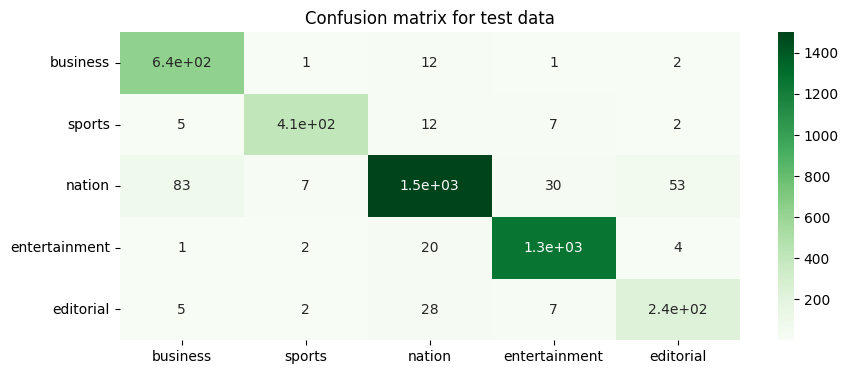

In [ ]:
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,average_precision_score,f1_score
confusion_mat = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10,4))
plt.title("Confusion matrix for test data")
plt.xlabel("Predicted class")
plt.ylabel("True class")

sns.heatmap(confusion_mat, annot=True, cmap="Greens",  xticklabels = target_names,
           yticklabels=target_names)
plt.show()

In [ ]:
# Function for predicting a sample text with the trained model

def predict_text_sample(test_text, inv_topic_dict, clf, count_vec):
  test_sample = [test_text]
  x_test_sample_fetaures = count_vec.transform(test_sample)
  y_pred_test_sample = clf.predict(x_test_sample_fetaures)

  return inv_topic_dict[y_pred_test_sample[0]]

In [ ]:
# This text is about some movie news from a telugu blogsite
test_text ="ఇండియన్ స్క్రీన్ మీద పోటీ పడటం అయిపోయింది అందుకే ఇప్పుడు మన సినిమాలు ఫారిన్ రిలీజ్ లో పోటీ పడుతున్నాయి. ఇండియన్ సినిమాలు ముఖ్యంగా సౌత్ సినిమాలు రిలీజ్ అవుతున్నాయి అంటే వరల్డ్ వైడ్ మార్కెట్ ఓపెన్ అవుతుంది. తెలుగు తమిళ హిందీ భాషల సినిమాలు సబ్ టైటిల్స్ తో విధేశాల్లో కూడా రిలీజ్ అవుతున్నాయి"

print("Prediced class is " , predict_text_sample(test_text, inv_topic_dict, clf, count_vec))

Prediced class is  entertainment


In [ ]:
# This sample text is about some political news from a telugu news website (Eenadu)

test_text = "హైదరాబాద్: తెలంగాణలో సంచలనం సృష్టించిన ‘ఎమ్మెల్యేలకు ఎర’ కేసులో హైకోర్టు కీలక తీర్పు వెల్లడించింది. ఈ కేసులో ముగ్గురు నిందితుల రిమాండ్‌కు ఉన్నత న్యాయస్థానం అనుమతించింది. నిందితులు వెంటనే సైబరాబాద్ కమిషనర్‌ స్టీఫెన్‌ రవీంద్ర ఎదుట లొంగిపోవాలని ఆదేశించింది. ఒకవేళ లొంగిపోకపోతే వారిని అరెస్టు చేసి ఏసీబీ కోర్టులో హాజరుపర్చాలని.. ఆ తర్వాత రిమాండ్‌కు తరలించాలని పోలీసులను ధర్మాసనం ఆదేశించింది."
print("Prediced class is " , predict_text_sample(test_text, inv_topic_dict, clf, count_vec))

Prediced class is  nation


In [ ]:
# This sample text is about some sports news from a telugu news website (Eenadu)

test_text = "టీ20 ప్రప్రంచకప్‌లో టీమ్‌ఇండియా ఆడటానికి ముందు న్యూజిలాండ్‌తో వార్మప్‌ మ్యాచ్‌ జరగాల్సి ఉంది. అయితే వర్షం కారణంగా రద్దైంది. ఆ తర్వాత పాకిస్థాన్‌తో మెల్‌బోర్న్‌ వేదికగా మ్యాచ్‌కు వరుణుడి గండం ఉందని వార్తలు వచ్చాయి. దీంతో సోషల్‌ మీడియాలో మీమ్స్‌ కూడా భారీ స్థాయిలో ట్రోల్‌ అయ్యాయి. అయితే వాతావరణం అనుకూలంగా మారడంతో దాయాదుల పోరును అక్టోబర్‌ 23న వీక్షించే అవకాశం అభిమానులకు దక్కింది. ఉత్కంఠపోరులో టీమ్‌ఇండియా విజయం సాధించిన విషయం తెలిసిందే. "
print("Prediced class is " , predict_text_sample(test_text, inv_topic_dict, clf, count_vec))

Prediced class is  sports
